# Bipolar Cell Simulation

## Introduction

Artificial neural networks (ANNs) have exploded in popularity over the past decade, but nature has been evolving neural networks for millions of years. In the modern day, animals are capable of an incredible variety of unique behaviors due to these diverse neural networks. It is nearly inconceivable to think that a human would be able to design a network better than that which has been naturally selected for over such a long span of time, thus it should come naturally to take inspiration from these biological mechanisms.

Computer vision is a common usage of neural networks. [1] An image or video feed is given to a neural network, and the network returns either object edges, estimated distances, or classifications of objects in frame. For robots to autonomously navigate unfamiliar terrain, this kind of sensory-based decision making is absolutely necessary. [1]

The human retina consists of three main types of cells that work together to transform light into spike trains which are then sent to the brain. The photoreceptors take in the initial light, and encode data for color and light intensity. [2] Then, the bipolar cells and horizontal cells find any sharp contrasts in color and light intensity, essentially acting as a natural edge detector. [2] Because bipolar cells are incapable of sending action potentials, they must send graded potentials to the retinal ganglion cells, which finally send the action potentials to the brain. [2]

A key component of segmentation is edge detection. Obviously, many methods already exist for detecting edges in images. The method most similar to a bipolar cell is the Laplacian filter, because its kernel closely mimics a center-surround formation. 

The center-surround mechanism consists of an inner circle and an outer circle, each of which respond to either light or dark. In an off-center bipolar cell for example, the center responds to darkness while the surrounding area responds to light. Inversely, an on-center bipolar cell's center responds to light while the surrounding area responds to darkness. In biology, this response would be the release, or lack of release, of neurotransmitters. [3][4] An off-center on-surround bipolar cell is shown in Figure 1.

![alt text](figures/centersurround.jpg)

Figure 1. Center-surround response for an off-center bipolar cell (Adapted from [3])

The goal of this experiment is to see how modeling a bipolar cell differs from existing edge detection techniques, specifically the Laplacian filter.

## Procedure

### Imports
The dataset comes from kaggle [5], so by using their "kagglehub" package the data can be downloaded directly to this working directory. If the dataset is already present, it will not be redownloaded. The benefit of using this method is that any updates to the dataset will be downloaded, even if the dataset is present.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500", output_dir="./dataset")

/home/grady/Coding/school/independent_research/bipolar-cell-simulation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

download('https://github.com/AllenDowney/ModSimPy/raw/master/' +
         'modsim.py')

from modsim import *

import cv2
import glob
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import distance_transform_edt
import scipy.io

### Dataset Loading
Having the dataset in the directory is good, but each individual image must be loaded in and represented in some way using Python. OpenCV is used in combination with glob in order to iteratively load in folders full of .jpg images. These .jpg files are saved as 2D numpy arrays in the python interpreter. A sample image from the test dataset is displayed at the bottom of the cell.

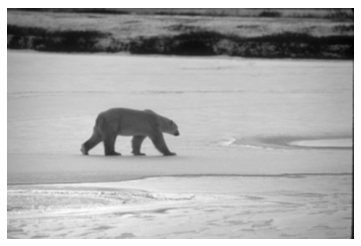

In [28]:
directory = "./dataset/images/test"

images = []
laplacian_images = []
for filename in sorted(glob.iglob(f'{directory}/*.jpg')):
    # Load the image in as grayscale
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    # Apply gaussian blur filter to image
    image = cv2.GaussianBlur(image, (3,3), 2)
    laplacian_images.append(cv2.Laplacian(image, cv2.CV_64F, ksize=3))
    images.append(image)

# Test image output

input_i = 0
input = images[input_i]
plt.imshow(input, cmap='gray')
plt.axis('off')
plt.show()


### Model Testing
The bipolar cell model was then tested on the same image displayed in the above dataset loading section. The model applies a modified version of a Laplacian filter, the kernel of which is shown in Figure 2. 

![alt text](figures/LaplacianKernel.png)

Figure 2. The Laplacian kernel used in the bipolar cell model

OpenCV has a built in "Laplacian" method, but the kernel is different from the one shown in Figure 2 [6]. Figure 3 shows this alternative Laplacian kernel.

![alt text](figures/opencvkernel.png)

Figure 3. The Laplacian kernel used by OpenCV's built-in method

This is a relatively small difference, but a difference nonetheless. More importantly, the bipolar cell is not doing a true convolution. Because it has a stride length of 3 and a kernel size of 3x3, each input pixel is used exactly once, and the resulting image is downscaled by a factor of 3. This is much more similar to how the retina works.

In the retina, there are many more photoreceptors than retinal ganglion cells. [7] The bipolar cells are the intermediate step in this pipeline, so it makes sense to downsample here by using a wider stride rather than doing a conventional convolution.

Additionally, a bipolar cell can be either off-center or on-center. The kernel shown in Figure 1 represents an off-center cell since the center pixel is negative, or inhibitory, while the surrounding pixels are positive, or excitatory.

So for the resulting filtered image, a positive pixel value indicates the strength of the response from the off-center cell in this case, while a negative pixel value indicates the strength of the response from the on-center cell. Thus, by clamping the negative values, the result is the ouput of the off-center bipolar cells only.

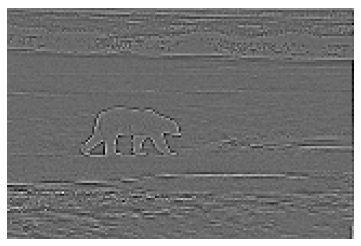

In [29]:
def bipolar_cell(input):
    kernel = np.array([
        [1, 1, 1],
        [1, -8, 1],
        [1, 1, 1]
    ])
    stride = 3
    result = []
    result_i = 0
    for row in range(1, input.shape[0], stride):
        result.append([])
        for col in range(1, input.shape[1], stride):
            slice = input[row-1:row+2]
            new_arr = []
            for i in range(slice.shape[0]):
                new_arr.append(slice[i][col-1:col+2])
            new_arr = np.array(new_arr)
            convolved_value = np.sum(new_arr * kernel)
            result[result_i].append(convolved_value)
        result_i += 1
    return np.array(result)

def off_center_cell(x):
    x = x*(255/x.max())
    return np.maximum(x, 0)

def on_center_cell(x):
    x = x*(255/x.min())
    return np.minimum(x, 0)

true_result = bipolar_cell(input)
result = cv2.resize(true_result, (input.shape[1], input.shape[0]), interpolation=cv2.INTER_NEAREST)
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()


(np.float64(-0.5), np.float64(480.5), np.float64(320.5), np.float64(-0.5))

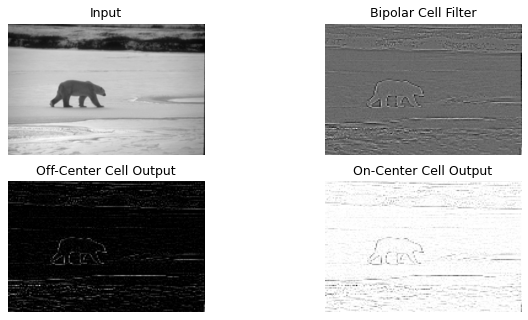

In [5]:
off_center = off_center_cell(result)

on_center = on_center_cell(result)

fig, ax = plt.subplots(2, 2, figsize=(10, 5))

ax[0][0].imshow(input, cmap='gray')
ax[0][0].set_title('Input')
ax[0][0].axis('off')

ax[0][1].imshow(result, cmap='gray')
ax[0][1].set_title('Bipolar Cell Filter')
ax[0][1].axis('off')

ax[1][0].imshow(off_center, cmap='gray')
ax[1][0].set_title('Off-Center Cell Output')
ax[1][0].axis('off')

ax[1][1].imshow(on_center, cmap='gray')
ax[1][1].set_title('On-Center Cell Output')
ax[1][1].axis('off')



### Effectiveness of Bipolar Cell vs Laplacian Filter

In this section, Pratt's Figure of Merit (FoM) is used to assign a score to each of the images that have been passed through the bipolar cell and Laplacian filters. The dataset provides ground truth images, and this equation scores the filtered image based on how far the detected edges were from the ground truth edges. The full equation for Pratt's FOM is given below.

$FOM(E,G) = \frac{1}{max(N_E, N_G)}\sum^{N_E}_{k=1}\frac{1}{1+\alpha d^2 (k)}$ (1)

In [6]:
directory = "./dataset/ground_truth/test"

true_images = []
for filename in sorted(glob.iglob(f'{directory}/*.mat')):
    # Load the image in as dictionary
    mat_dic = scipy.io.loadmat(filename)
    image = mat_dic['groundTruth'][0][0][0][0][1]
    true_images.append(image)

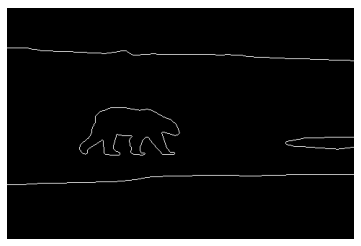

In [7]:
plt.imshow(true_images[input_i], cmap='gray')
plt.axis('off')
plt.show()

In [30]:
def convert_to_binary(x):
    copy_x = x.copy()
    if copy_x.max() > 1.0:
        threshold = 20 
    else:
        threshold = 20.0/255
    copy_x[copy_x<=threshold] = 0
    copy_x[copy_x>threshold] = 1
    return copy_x

def fom(detected_img, ideal_img, alpha=1.0 / 9.0):
    
    detected_edge = convert_to_binary(detected_img)
    ideal_edge = convert_to_binary(ideal_img)

    # Use scipy to determine distance from detected edge to ideal edge
    dist_map = distance_transform_edt(1 - ideal_edge)
    distances = dist_map[detected_edge == 1]
    
    # Compute FOM using formula
    sum = np.sum(1.0 / (1.0 + alpha * (distances ** 2)))
    max_edges = max(np.sum(ideal_edge), np.sum(detected_edge))
    fom = (1.0 / max_edges) * sum
    
    return fom

bipolar_images = []
for image in images:
    result = bipolar_cell(image)
    result = cv2.resize(result, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    bipolar_images.append(result)

In [33]:
bipolar_foms = []
laplacian_foms = []

for image_i in range(len(bipolar_images)):
    bipolar_foms.append(fom(bipolar_images[image_i], true_images[image_i]))
    laplacian_foms.append(fom(laplacian_images[image_i], true_images[image_i]))

bipolar_foms = np.array(bipolar_foms)
laplacian_foms = np.array(laplacian_foms)
differences = bipolar_foms - laplacian_foms
avg_dif = np.mean(differences)

### Retinal Ganglion Cell (RGC) Output
The retinal pathway goes from bipolar cells to RGCs. Bipolar cells most often do not create action potentials, or spikes. Instead, they send graded potentials to the RGCs, which then propagate action potentials down the visual pathway to the brain. [8] In this example, the light intensity that is output from the bipolar cell is used as the frequency of the spikes produced by the RGC.

In a future work, these spikes could be fed into a spike neural network in order to produce some form of output. For example, the input could be a live video feed and the spikes could be fed to a spike neural network that controls motor function, either physically or digitally. Or, the spike neural network could segment or classify the objects in the input images.

Im:  10


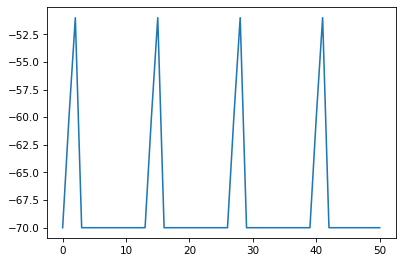

In [9]:
neuron = System (e_l = -70,
                g_l = 0.1,
                v_thresh = -50,
                v_reset = -70,
                t_ref = 10)

def update_voltage(v_m, i_m, neuron):
  delta_v_m = neuron.g_l*(neuron.e_l - v_m) + i_m
  new_v_m = v_m + delta_v_m
  return new_v_m

def run_simulation(neuron, update, i_m):
  neuron_data = TimeSeries()
  time_steps = 50
  neuron_data[0] = neuron.e_l
  wait_t = 0
  for t in range(time_steps):
    if wait_t <= 0:
      new_v_m = update(neuron_data[t], i_m, neuron)
      if new_v_m >= neuron.v_thresh:
        new_v_m = neuron.v_reset
        wait_t = neuron.t_ref
    else:
      wait_t -= 1
    neuron_data[t+1] = new_v_m
  return neuron_data

i_m = 10
print("Im: ", i_m)
results = run_simulation(neuron, update_voltage, i_m)
plt.plot(results)

## Results

In [35]:
print("Min:",differences.min())
print("Max:",differences.max())
print("Mean:",avg_dif)

Min: -0.028293429328927533
Max: 0.07318083334627257
Mean: 0.004770864104868888


The bipolar cell averaged 0.0048 higher than the standard Laplacian filter on the Pratt's FOM test. Additionally, the minimum difference in FOM value was -0.0283 and the maximum difference was 0.0732. 

## Conclusion

The bipolar cell produced slightly better results on average than a traditional Laplacian filter while being computationally more efficient. The difference is relatively small, but it is interesting that by computing less and being more true to biology the end result is higher accuracy.

For future work, the study should also compare the current state of the art edge detection method so as to better understand how significant the observed improvement is. Additionally, more work could be done to utilize the RGC output and to integrate this experiment with a full spike neural network.

## References

[1] D. A. Pomerleau, “Efficient training of artificial neural networks for
autonomous navigation,” Neural Computation, vol. 3, no. 1, pp. 88–97,
1991.

[2] H. S. Seung and U. S¨umb¨ul, “Neuronal cell types and connectivity:
lessons from the retina,” Neuron, vol. 83, no. 6, pp. 1262–1272, 2014

[3] “Perception lecture notes: Retinal ganglion cells,” https://www.cns.nyu.
edu/∼david/courses/perception/lecturenotes/ganglion/ganglion.html, ac-
cessed 2026-05-03.

[4] P. H. Schiller, J. H. Sandell, and J. H. Maunsell, “Functions of the on
and off channels of the visual system,” Nature, vol. 322, no. 6082, pp.
824–825, 19

[5] “Berkley segmentation dataset 500 (bsds500),” https://www.kaggle.
com/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500, ac-
cessed 2026-05-03.

[6] “Edge detection using opencv,” https://opencv.org/
edge-detection-using-opencv/, accessed 2026-05-03.

[7] U. S. Kim, O. A. Mahroo, J. D. Mollon, and P. Yu-Wai-Man, “Retinal
ganglion cells—diversity of cell types and clinical relevance,” Frontiers
in neurology, vol. 12, p. 661938, 2021.

[8] S. Saszik and S. H. DeVries, “A mammalian retinal bipolar cell uses
both graded changes in membrane voltage and all-or-nothing na+ spikes
to encode light,” Journal of Neuroscience, vol. 32, no. 1, pp. 297–307,
2012.